In [ ]:
import yfinance as yf
import os
 
# 设置网络代理
proxy = 'http://127.0.0.1:10808'
os.environ['HTTP_PROXY'] = proxy
os.environ['HTTPS_PROXY'] = proxy

# 获取股票数据
symbol = "600519.SS"
start_date = "2022-01-01"
end_date = "2023-01-01"

data = yf.download(symbol, start=start_date, end=end_date)
print(data.head())

[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open    Volume
Ticker        600519.SS    600519.SS    600519.SS    600519.SS 600519.SS
Date                                                                    
2022-01-04  1814.803223  1830.480772  1781.864406  1818.138706   3384262
2022-01-05  1790.712036  1826.986341  1785.403601  1809.291558   2839551
2022-01-06  1753.747681  1801.328980  1715.075765  1788.951487   5179475
2022-01-07  1718.163574  1759.640153  1715.792426  1747.359969   2981669
2022-01-10  1739.397217  1749.129348  1696.531647  1705.785984   2962670


Matplotlib is building the font cache; this may take a moment.
[*********************100%***********************]  1 of 1 completed


Price         Close         High          Low         Open        Volume
Ticker    600519.SS    600519.SS    600519.SS    600519.SS     600519.SS
count    242.000000   242.000000   242.000000   242.000000  2.420000e+02
mean    1599.777939  1619.893295  1581.455278  1600.488045  3.385434e+06
std      125.488528   123.652226   127.508121   126.799169  1.778336e+06
min     1207.288452  1235.914612  1192.085561  1207.288452  1.354417e+06
25%     1550.104980  1565.988184  1519.568332  1542.869951  2.216221e+06
50%     1598.788452  1624.159671  1585.894898  1604.209073  2.835084e+06
75%     1688.110992  1706.077562  1675.253802  1693.626842  3.929750e+06
max     1828.818481  1857.435690  1802.177666  1837.761412  1.320980e+07


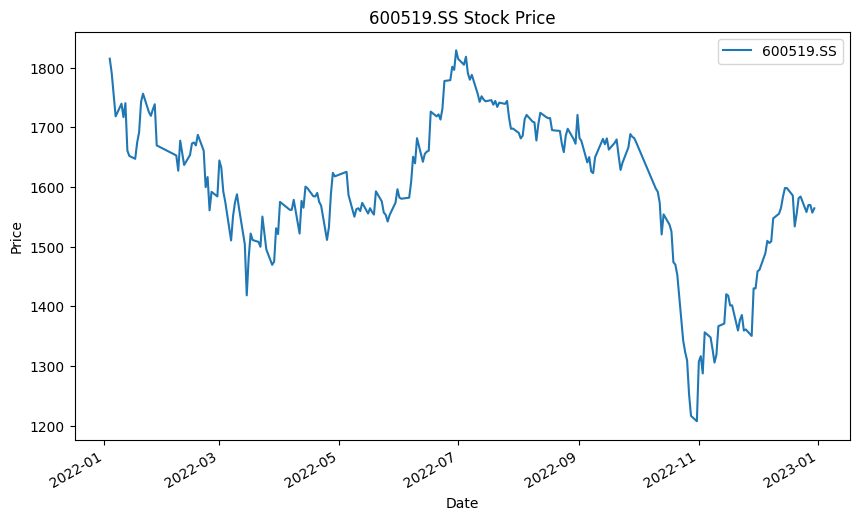

In [8]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 获取股票数据
symbol = "600519.SS"
start_date = "2022-01-01"
end_date = "2023-01-01"

data = yf.download(symbol, start=start_date, end=end_date)
# 简单的数据分析
print(data.describe())

# 绘制股价走势图
data['Close'].plot(figsize=(10, 6), label=symbol)
plt.title(f"{symbol} Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

[*********************100%***********************]  1 of 1 completed


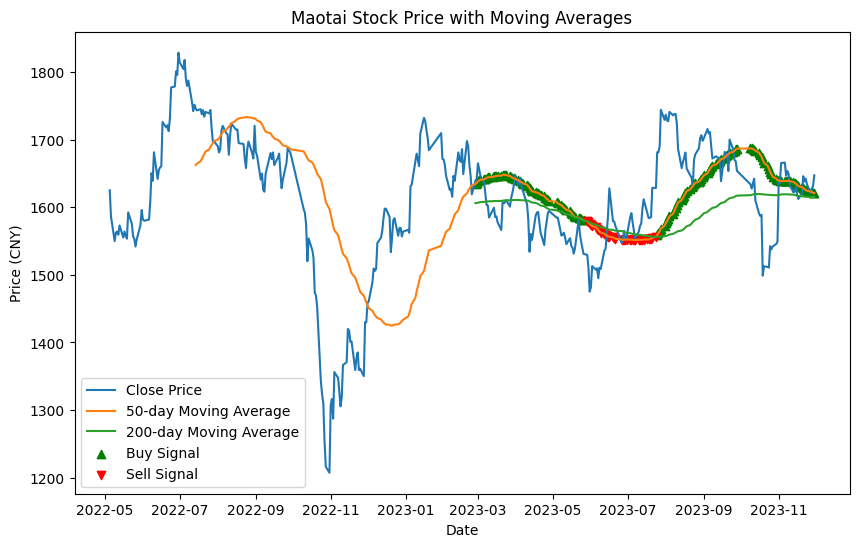

In [10]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# 获取贵州茅台股票数据
symbol = "600519.SS"
start_date = "2022-05-01"
end_date = "2023-12-01"

data = yf.download(symbol, start=start_date, end=end_date)

# 计算短期（50天）和长期（200天）移动平均
data['MA_50'] = data['Close'].rolling(window=50).mean()
data['MA_200'] = data['Close'].rolling(window=200).mean()

# 生成买卖信号
data['Signal'] = 0
# 使用 .loc 避免链式赋值
data.loc[data['MA_50'] > data['MA_200'], 'Signal'] = 1  # 短期均线上穿长期均线，产生买入信号
data.loc[data['MA_50'] < data['MA_200'], 'Signal'] = -1  # 短期均线下穿长期均线，产生卖出信号
# data['Signal'][data['MA_50'] > data['MA_200']] = 1  # 短期均线上穿长期均线，产生买入信号
# data['Signal'][data['MA_50'] < data['MA_200']] = -1  # 短期均线下穿长期均线，产生卖出信号

# 绘制股价和移动平均线
plt.figure(figsize=(10, 6))
plt.plot(data['Close'], label='Close Price')
plt.plot(data['MA_50'], label='50-day Moving Average')
plt.plot(data['MA_200'], label='200-day Moving Average')

# 标记买卖信号
plt.scatter(data[data['Signal'] == 1].index, data[data['Signal'] == 1]['MA_50'], marker='^', color='g', label='Buy Signal')
plt.scatter(data[data['Signal'] == -1].index, data[data['Signal'] == -1]['MA_50'], marker='v', color='r', label='Sell Signal')

plt.title("Maotai Stock Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (CNY)")
plt.legend()
plt.show()

[*********************100%***********************]  1 of 1 completed


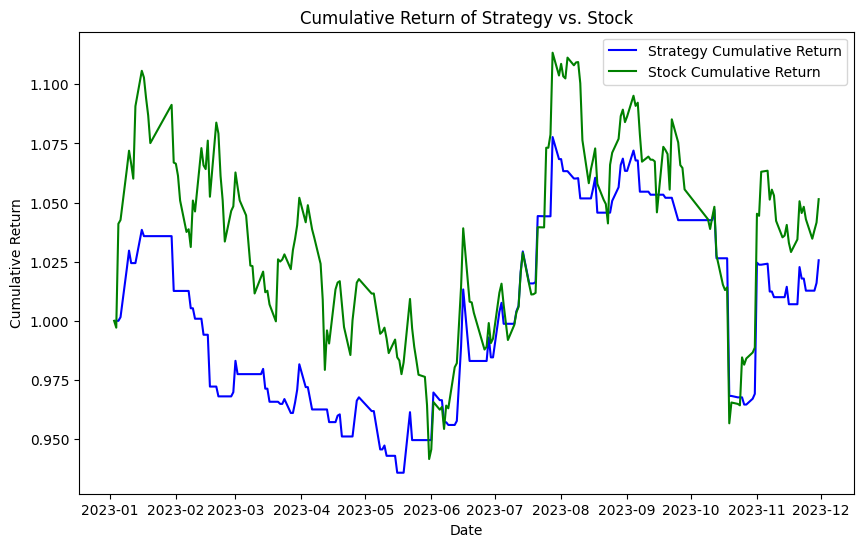

In [11]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 获取股票数据
symbol = "600519.SS"
start_date = "2023-01-01"
end_date = "2023-12-01"

data = yf.download(symbol, start=start_date, end=end_date)

# 初始化交叉信号列
data['Signal'] = 0

# 计算每日收益率
data['Daily_Return'] = data['Close'].pct_change()

# 计算策略信号
data['Signal'] = 0
data.loc[data['Daily_Return'] > 0, 'Signal'] = 1  # 以涨幅为信号，可根据需要修改条件

# 计算策略收益
data['Strategy_Return'] = data['Signal'].shift(1) * data['Daily_Return']

# 计算累计收益
data['Cumulative_Return'] = (1 + data['Strategy_Return']).cumprod()

# 绘制累计收益曲线
plt.figure(figsize=(10, 6))
plt.plot(data['Cumulative_Return'], label='Strategy Cumulative Return', color='b')
plt.plot(data['Close'] / data['Close'].iloc[0], label='Stock Cumulative Return', color='g')
plt.title("Cumulative Return of Strategy vs. Stock")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.show()